# Task 2: Yelp polarity sentiment classification

Poushali Purkayastha, Team 16.

This notebook runs the whole Task 2 pipeline: EDA and preprocessing, training of the baseline and two experimental models, the full metric suite, and the error-review candidate selection. The code lives in the modules next to this notebook (`preprocess.py`, `models.py`, `train.py`, `evaluate_task2.py`, `run.py`). The config is read from the `TASK2_CONFIG` environment variable and defaults to `configs/full.yaml`; `configs/smoke.yaml` is the small CPU test.

In [1]:
import os
import runpy
import sys
from pathlib import Path

CONFIG = os.environ.get("TASK2_CONFIG", "configs/full.yaml")
print("config:", CONFIG)
sys.argv = ["run.py", "--config", CONFIG]
runpy.run_path("run.py", run_name="__main__")

config: configs/smoke.yaml


2026-09-21 16:20:50,490 INFO run_id smoke_20260921_162050 member Poushali_Purkayastha task task2_sentiment models baseline,textcnn,bilstm


2026-09-21 16:20:50,494 INFO config task2_sentiment/Poushali_Purkayastha/src/configs/smoke.yaml {"run_name": "smoke", "is_final": false, "seed": 20, "data": {"hf_dataset": "fancyzhx/yelp_polarity", "eda_rows": 20000, "n_train": 3000, "n_val": 300, "n_test": 2000, "max_len": 128, "vocab_size": 5000, "min_freq": 1, "remove_stopwords": true, "keep_negations": true, "stem": true}, "models": {"baseline": {"type": "mean_mlp", "embed_dim": 32, "hidden_dim": 32, "dropout": 0.3, "lr": 0.001, "epochs": 1, "batch_size": 64}, "textcnn": {"type": "textcnn", "embed_dim": 32, "n_filters": 16, "kernel_sizes": [3, 4, 5], "dropout": 0.5, "lr": 0.001, "epochs": 1, "batch_size": 64}, "bilstm": {"type": "bilstm", "embed_dim": 32, "hidden_dim": 32, "n_layers": 1, "dropout": 0.3, "lr": 0.001, "epochs": 1, "batch_size": 64}}, "train": {"weight_decay": 0.0, "grad_clip": 1.0, "amp": true, "log_interval": 10, "eval_batch_size": 256}, "evaluation": {"baseline": "baseline", "bootstrap_samples": 100, "ece_bins": 10

2026-09-21 16:20:50,497 INFO hardware {"platform": "Windows-11-10.0.26200-SP0", "python": "3.12.10", "torch": "2.14.0+cpu", "cpu": "Intel64 Family 6 Model 140 Stepping 1, GenuineIntel", "cpu_cores": 8, "ram_gb": 16.9, "cuda_available": false, "cuda_version": null, "gpus": [], "nvidia_smi": "no gpu"}


2026-09-21 16:20:50,498 INFO git {"commit": "3ce84b78d08bcba1ceb0b85d0e1046432790631b", "branch": "main", "dirty": true}


...

2026-09-21 16:21:04,264 INFO McNemar bilstm vs baseline: b 294 c 480 statistic 44.218 p 2.937e-11


2026-09-21 16:21:04,264 INFO error review candidates for bilstm: 20 rows, worst slice {"slice": "length_bucket=long", "support": 629, "macro_f1": 0.5318518743544565, "error_rate": 0.46740858505564387}


2026-09-21 16:21:04,988 INFO manifest reproducibility/manifests/Poushali_Purkayastha_task2_sentiment_smoke_20260921_162050.json


2026-09-21 16:21:04,989 INFO run finished in 14.6 sec


{'__name__': '__main__',
 '__doc__': None,
 '__package__': '',
 '__loader__': None,
 '__spec__': None,
 '__file__': 'run.py',
 '__cached__': None,
 '__builtins__': {'__name__': 'builtins',
  '__doc__': "Built-in functions, types, exceptions, and other objects.\n\nThis module provides direct access to all 'built-in'\nidentifiers of Python; for example, builtins.len is\nthe full name for the built-in function len().\n\nThis module is not normally accessed explicitly by most\napplications, but can be useful in modules that provide\nobjects with the same name as a built-in value, but in\nwhich the built-in of that name is also needed.",
  '__package__': '',
  '__loader__': _frozen_importlib.BuiltinImporter,
  '__spec__': ModuleSpec(name='builtins', loader=<class '_frozen_importlib.BuiltinImporter'>, origin='built-in'),
  '__build_class__': <function __build_class__>,
  '__import__': <function __import__(name, globals=None, locals=None, fromlist=(), level=0)>,
  'abs': <function abs(x, /)>,

,Metric,baseline,textcnn,bilstm
0,Accuracy,0.5055,0.6,0.5985
1,Precision (macro),0.6103912601626016,0.6007669214662328,0.6034682782999112
2,Recall (macro),0.5069520625685631,0.5998583987255885,0.5988188893700044
3,F1 (macro),0.35544313284616824,0.5990372885297599,0.5940671113729707
4,Precision (micro),0.5055,0.6,0.5985
5,Recall (micro),0.5055,0.6,0.5985
6,F1 (micro),0.5055,0.6,0.5985
7,Precision (weighted),0.6107163363821138,0.600742702893615,0.60353858412491
8,Recall (weighted),0.5055,0.6,0.5985
9,F1 (weighted),0.3545101367809631,0.599096230048346,0.5939398514123861


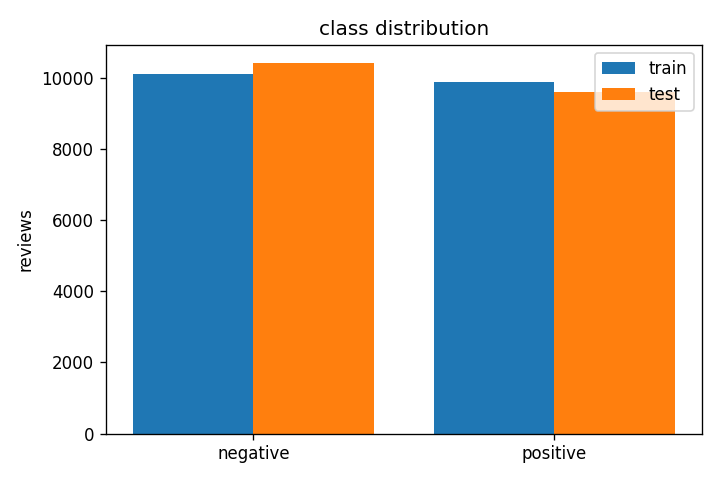

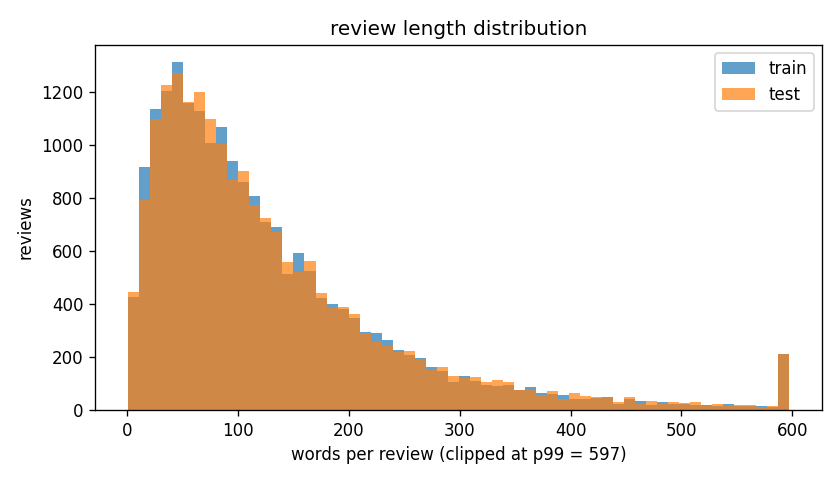

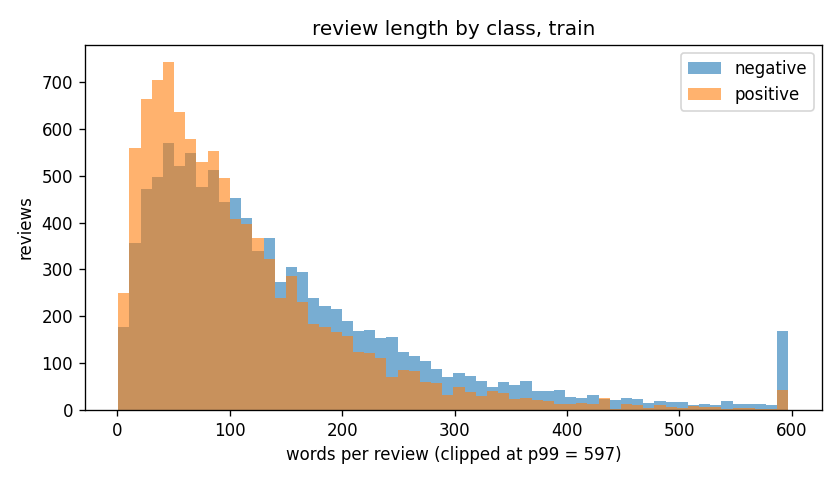

### baseline

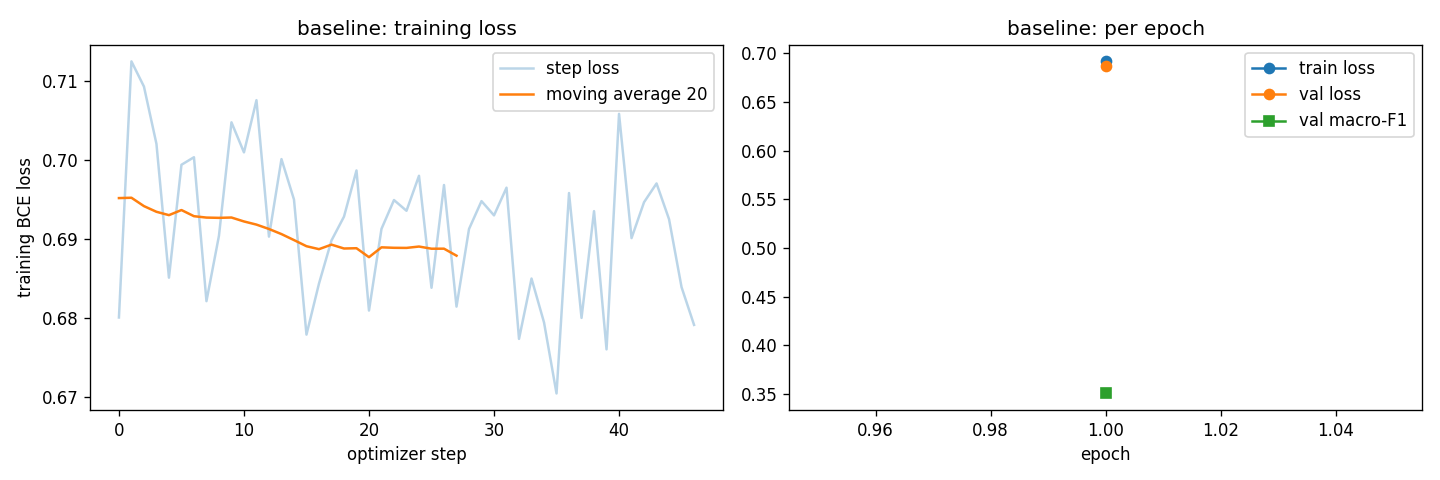

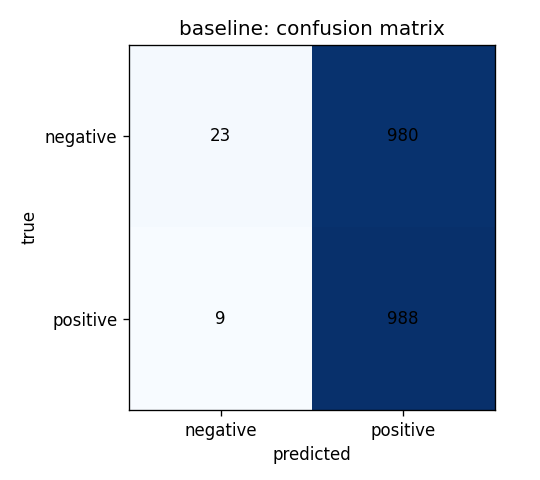

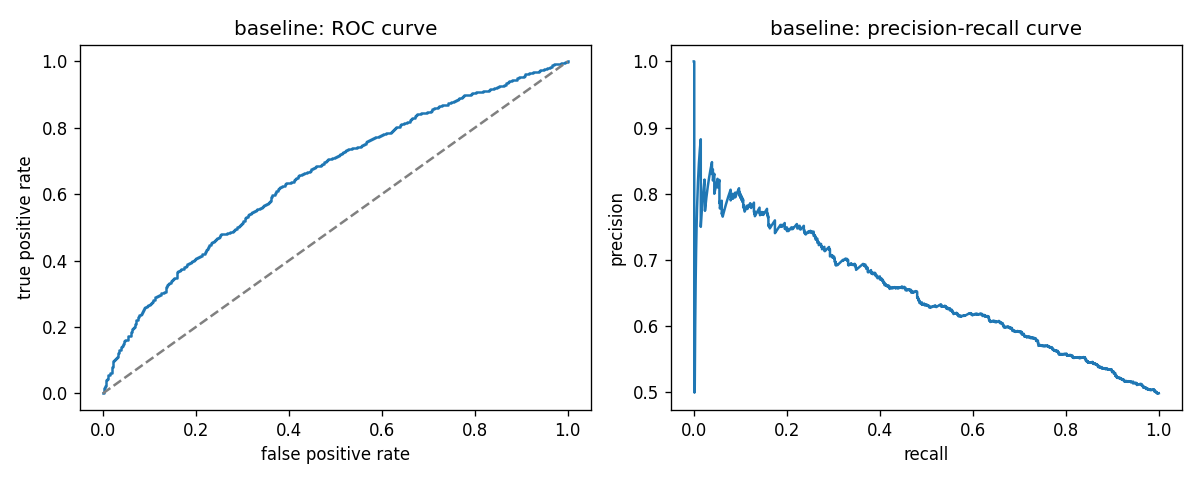

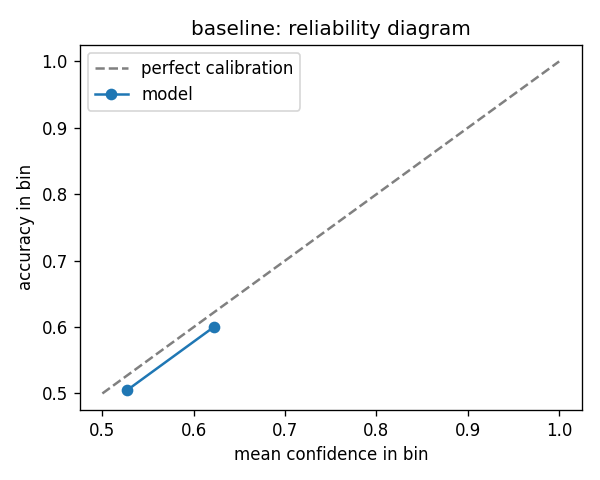

### bilstm

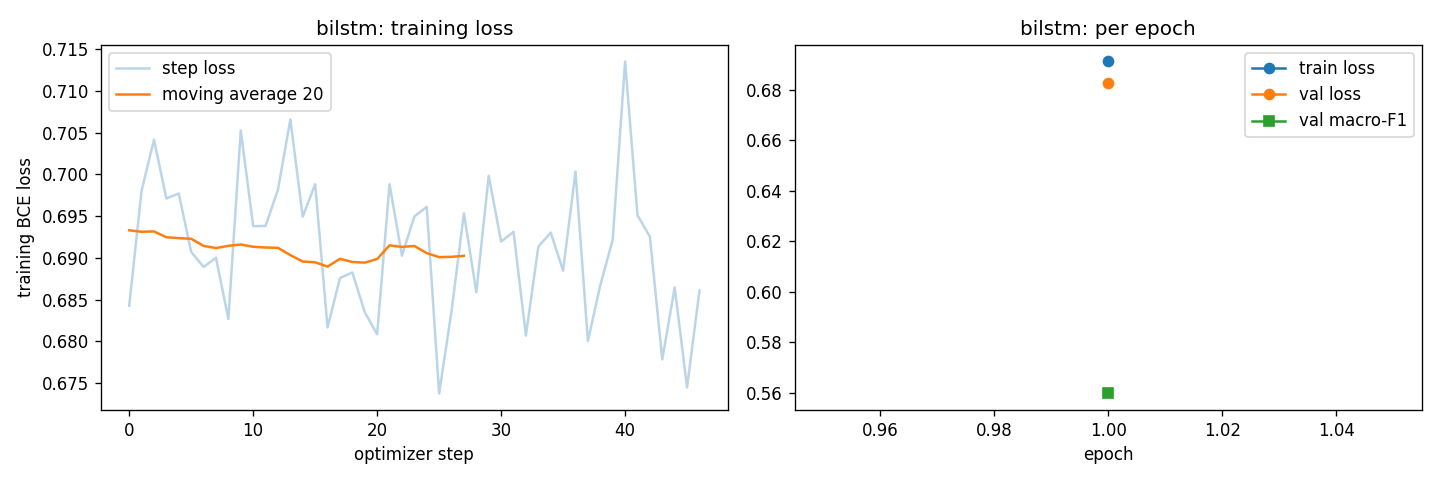

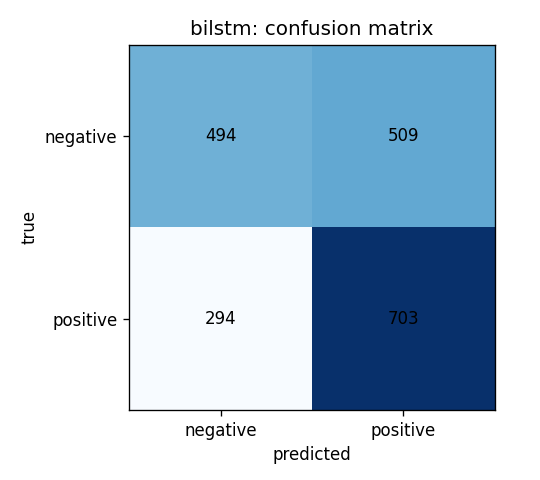

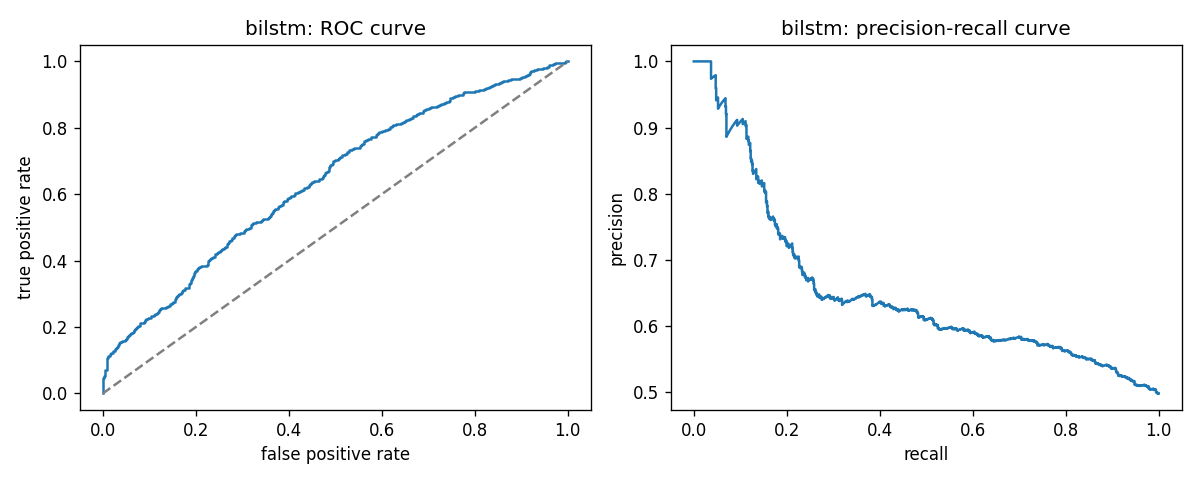

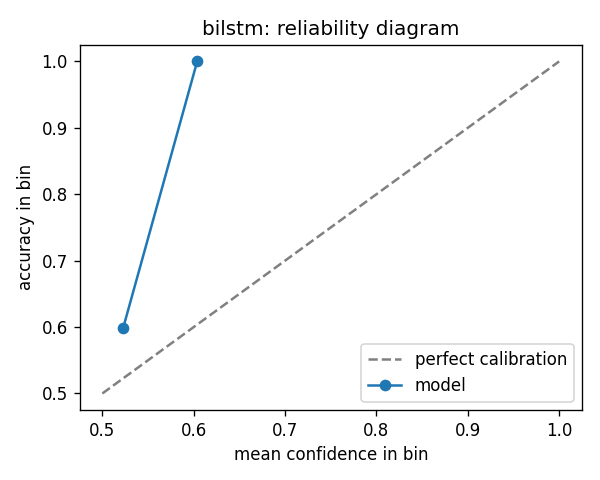

### textcnn

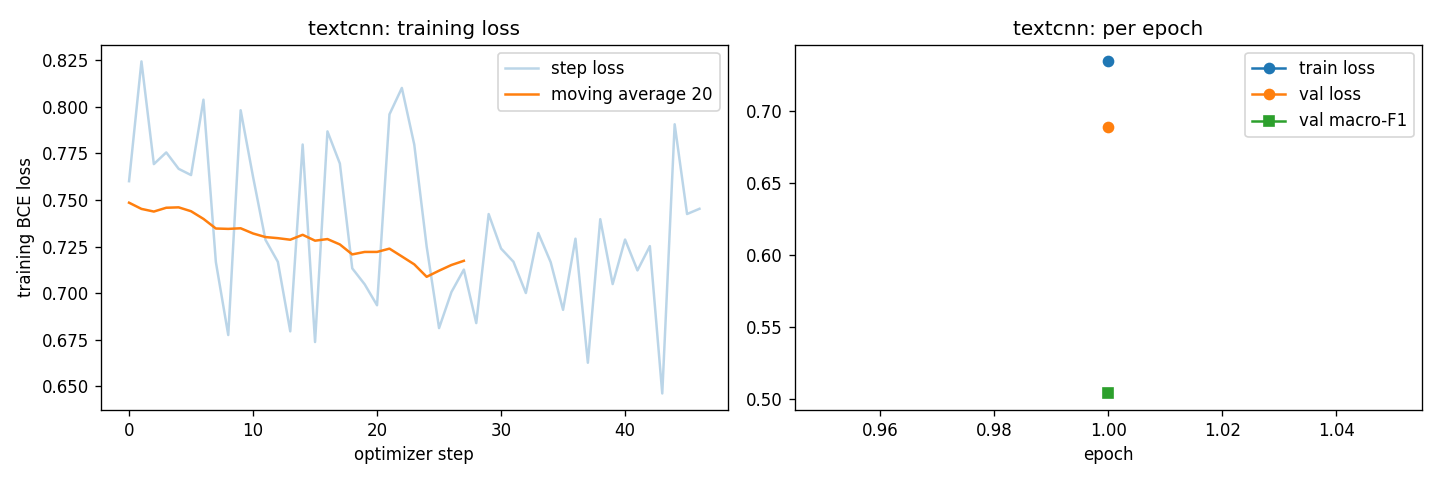

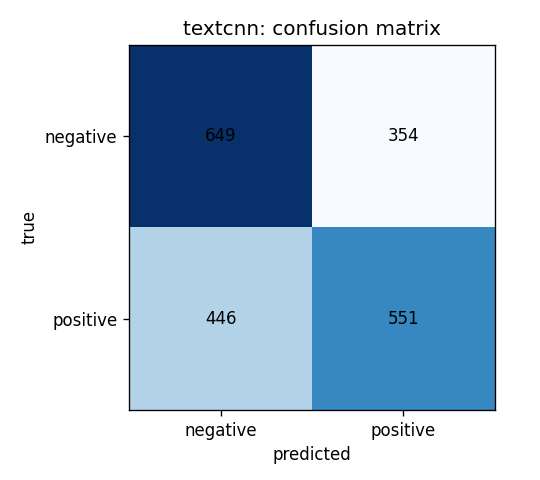

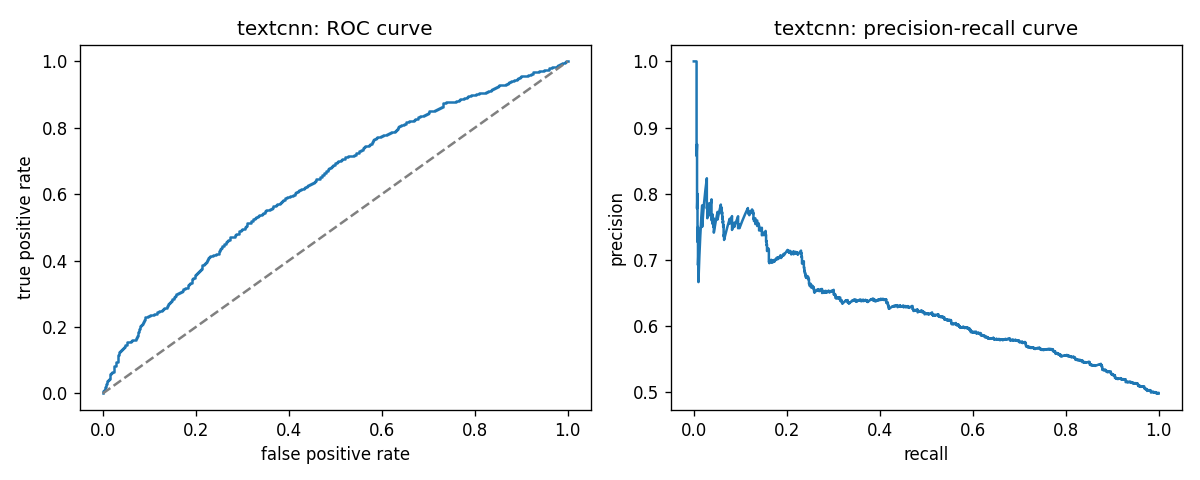

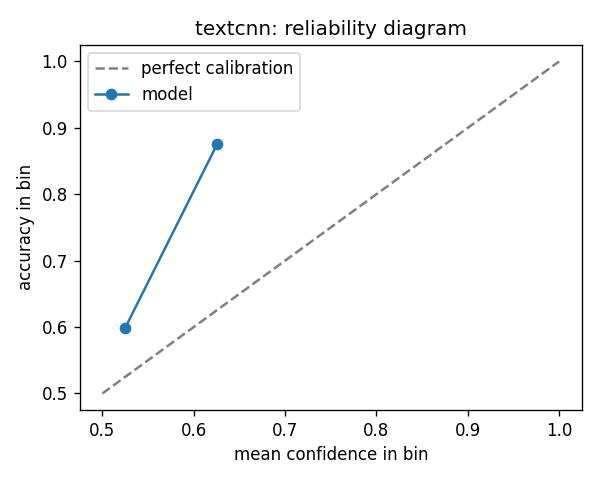

# Error review candidates

## confident_false_positive | test index 589 | label 0 | predicted 1 | p(positive) = 0.566 | 215 words | negation 1 | but 1 | exclamation 0

I love a good steak and have no problem paying for one, but Prime's is not worth the price. We had two different cuts, the porterhouse and the dry-aged bone-in ribeye. The quality of the steak might have been there, but the preparation of it threw the whole thing off. However, I did really like the sauce that accompanied the steaks, so much so that we requested some in leftover box. We had truffle mashed potatoes that were divine (but honestly, it's truffle so how bad could it be?) but the glazed carrots were tangy, which I did not like at all. As for the appetizers, we shared the Caesar salad which was fabulous. The presentation was unique in that it was a whole head of romaine lettuce (I'll post a picture).  Service was confusing to say the least. Our server was very nice and friendly, but very condescending. Maybe it 

In [2]:
import pandas as pd
import yaml
from IPython.display import Image, Markdown, display

run_name = yaml.safe_load(Path(CONFIG).read_text(encoding="utf-8"))["run_name"]
out_dir = Path("..") / "outputs" / run_name
pd.set_option("display.max_rows", 200)
display(pd.read_csv(out_dir / "metrics_wide.csv"))
for name in ["eda_class_distribution.png", "eda_length_distribution.png", "eda_length_by_class.png"]:
    display(Image(filename=str(out_dir / "eda" / name)))
for model_dir in sorted(p for p in out_dir.iterdir() if (p / "test_probs.npy").exists()):
    display(Markdown(f"### {model_dir.name}"))
    for name in ["curves.png", "confusion_matrix.png", "roc_pr_curves.png", "calibration.png"]:
        display(Image(filename=str(model_dir / name)))
candidates = sorted(out_dir.glob("*/error_review_candidates.md"))
if candidates:
    print(candidates[0].read_text(encoding="utf-8")[:6000])